In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
pathfig=pathfile+'figures/'
os.chdir(pathfile)

addtotitle='_03022026_woMA_for_RD_MD_AD_FA' # to specify the version of the data

metricsDTI='FA' # to specify the DTI metric to use for the analysis



#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
scaler = RobustScaler()

DTI_all=np.zeros((42, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((42, 98, 7))  # 10 DTI metrics

for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_{metricsDTI}{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC

 # target var

import seaborn as sns
selection=[0,42]
Aging_INDICES=Aging_INDICES_all[selection[0]:selection[1]] # only the 42 subjects  
DTI=DTI_all[selection[0]:selection[1],:,:]  # only the 42 subjects 
DTI_scaled=DTI_all_scaled[selection[0]:selection[1],:,:]  

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']


ADJUST DATA DTI remove age effect on dti_scaled


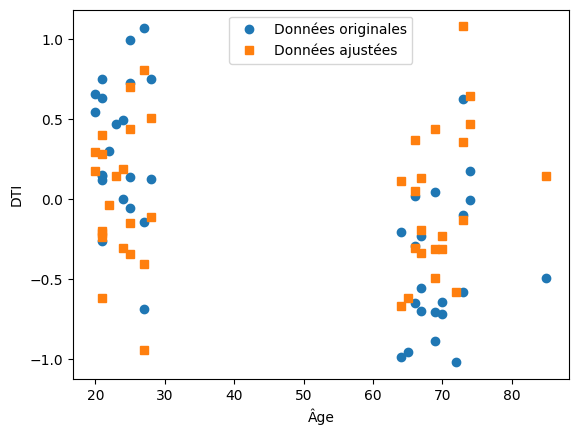

In [105]:
import statsmodels.api as sm

DTI_adjusted = np.zeros_like(DTI_scaled)  # pour stocker les données DTI ajustées

for cc in range(7):
    for seg in range(98):
        data = DTI_scaled[:,seg,cc]  # on prend les données DTI du CC1 pour l'exemple

        data_adjusted = data.copy()

        ### enlever l'effet de l'âge sur le DTI

        # Ajouter une constante à la variable indépendante
        X = sm.add_constant(age)
        y = data

        # Créer le modèle de régression multiple
        model = sm.OLS(y, X)

        # Ajuster le modèle
        results = model.fit()   

        # Calculer les résidus
        residuals = results.resid

        # Mettre à jour les données DTI avec les résidus
        data_adjusted = residuals

        DTI_adjusted[:,seg,cc] = data_adjusted  # stocker les données ajustées  


DTI_scaled_saved=DTI_scaled.copy()  # sauvegarder les données DTI originales
DTI_scaled=DTI_adjusted.copy()  # utiliser les données DTI ajustées

plt.plot(age, DTI_scaled_saved[:,10,4], 'o', label='Données originales')
plt.plot(age, DTI_scaled[:,10,4], 's', label='Données ajustées')
plt.xlabel('Âge')
plt.ylabel('DTI')
plt.legend()
plt.show()

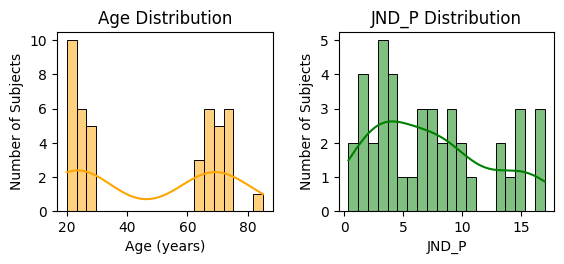

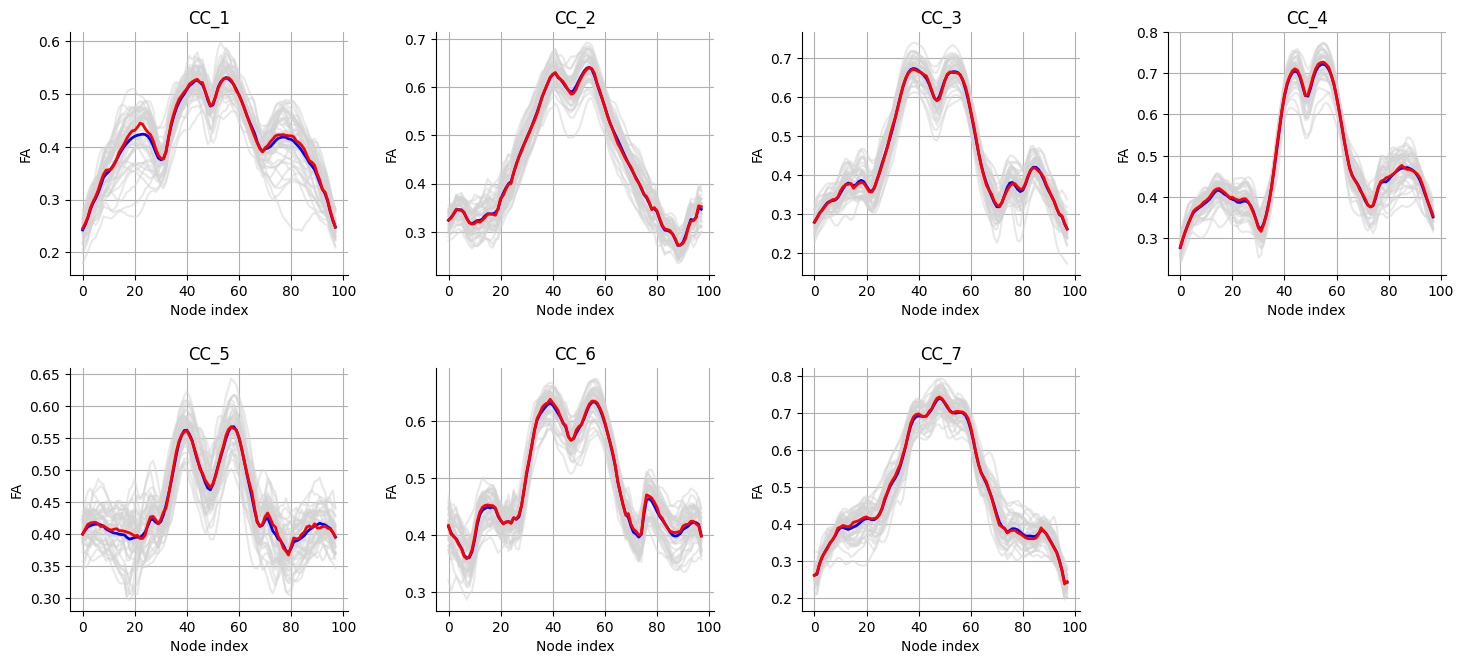

In [106]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel(metricsDTI)
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)


Feat selectio based on simple lin regression using f_regression

Feat selection based on simple linear regression using f_regression

CC 1 - Best features for JND: [94 95 93 76 46 86 77 87 49  6]
CC 1 - Best features for Age: [25 24 28 29 27 11 26 76 80 82]
CC 2 - Best features for JND: [96 13  7 87 94 86  5 97 85 73]
CC 2 - Best features for Age: [17 76 71 70 16 62 51 19 23 35]
CC 3 - Best features for JND: [91 92 93 90 94 89 97  8 38 39]
CC 3 - Best features for Age: [22 23 66 24 55 42 27 43 39 20]
CC 4 - Best features for JND: [89 97 88 90 87  7  8 86 96 91]
CC 4 - Best features for Age: [43 77 78 70 63 68 53 75 82 81]
CC 5 - Best features for JND: [59 60 79 18 61 17 78 80 83 81]
CC 5 - Best features for Age: [56 41 46 48 54 85 45  3 39 38]
CC 6 - Best features for JND: [52 97 53 54 51 96 55 49 50 35]
CC 6 - Best features for Age: [78 76 83 82  3 16 12 49 42 62]
CC 7 - Best features for JND: [52 42 53 47 41 51 48 46 43 40]
CC 7 - Best features for Age: [37 39  1 36 21 24  2 91 34 20]


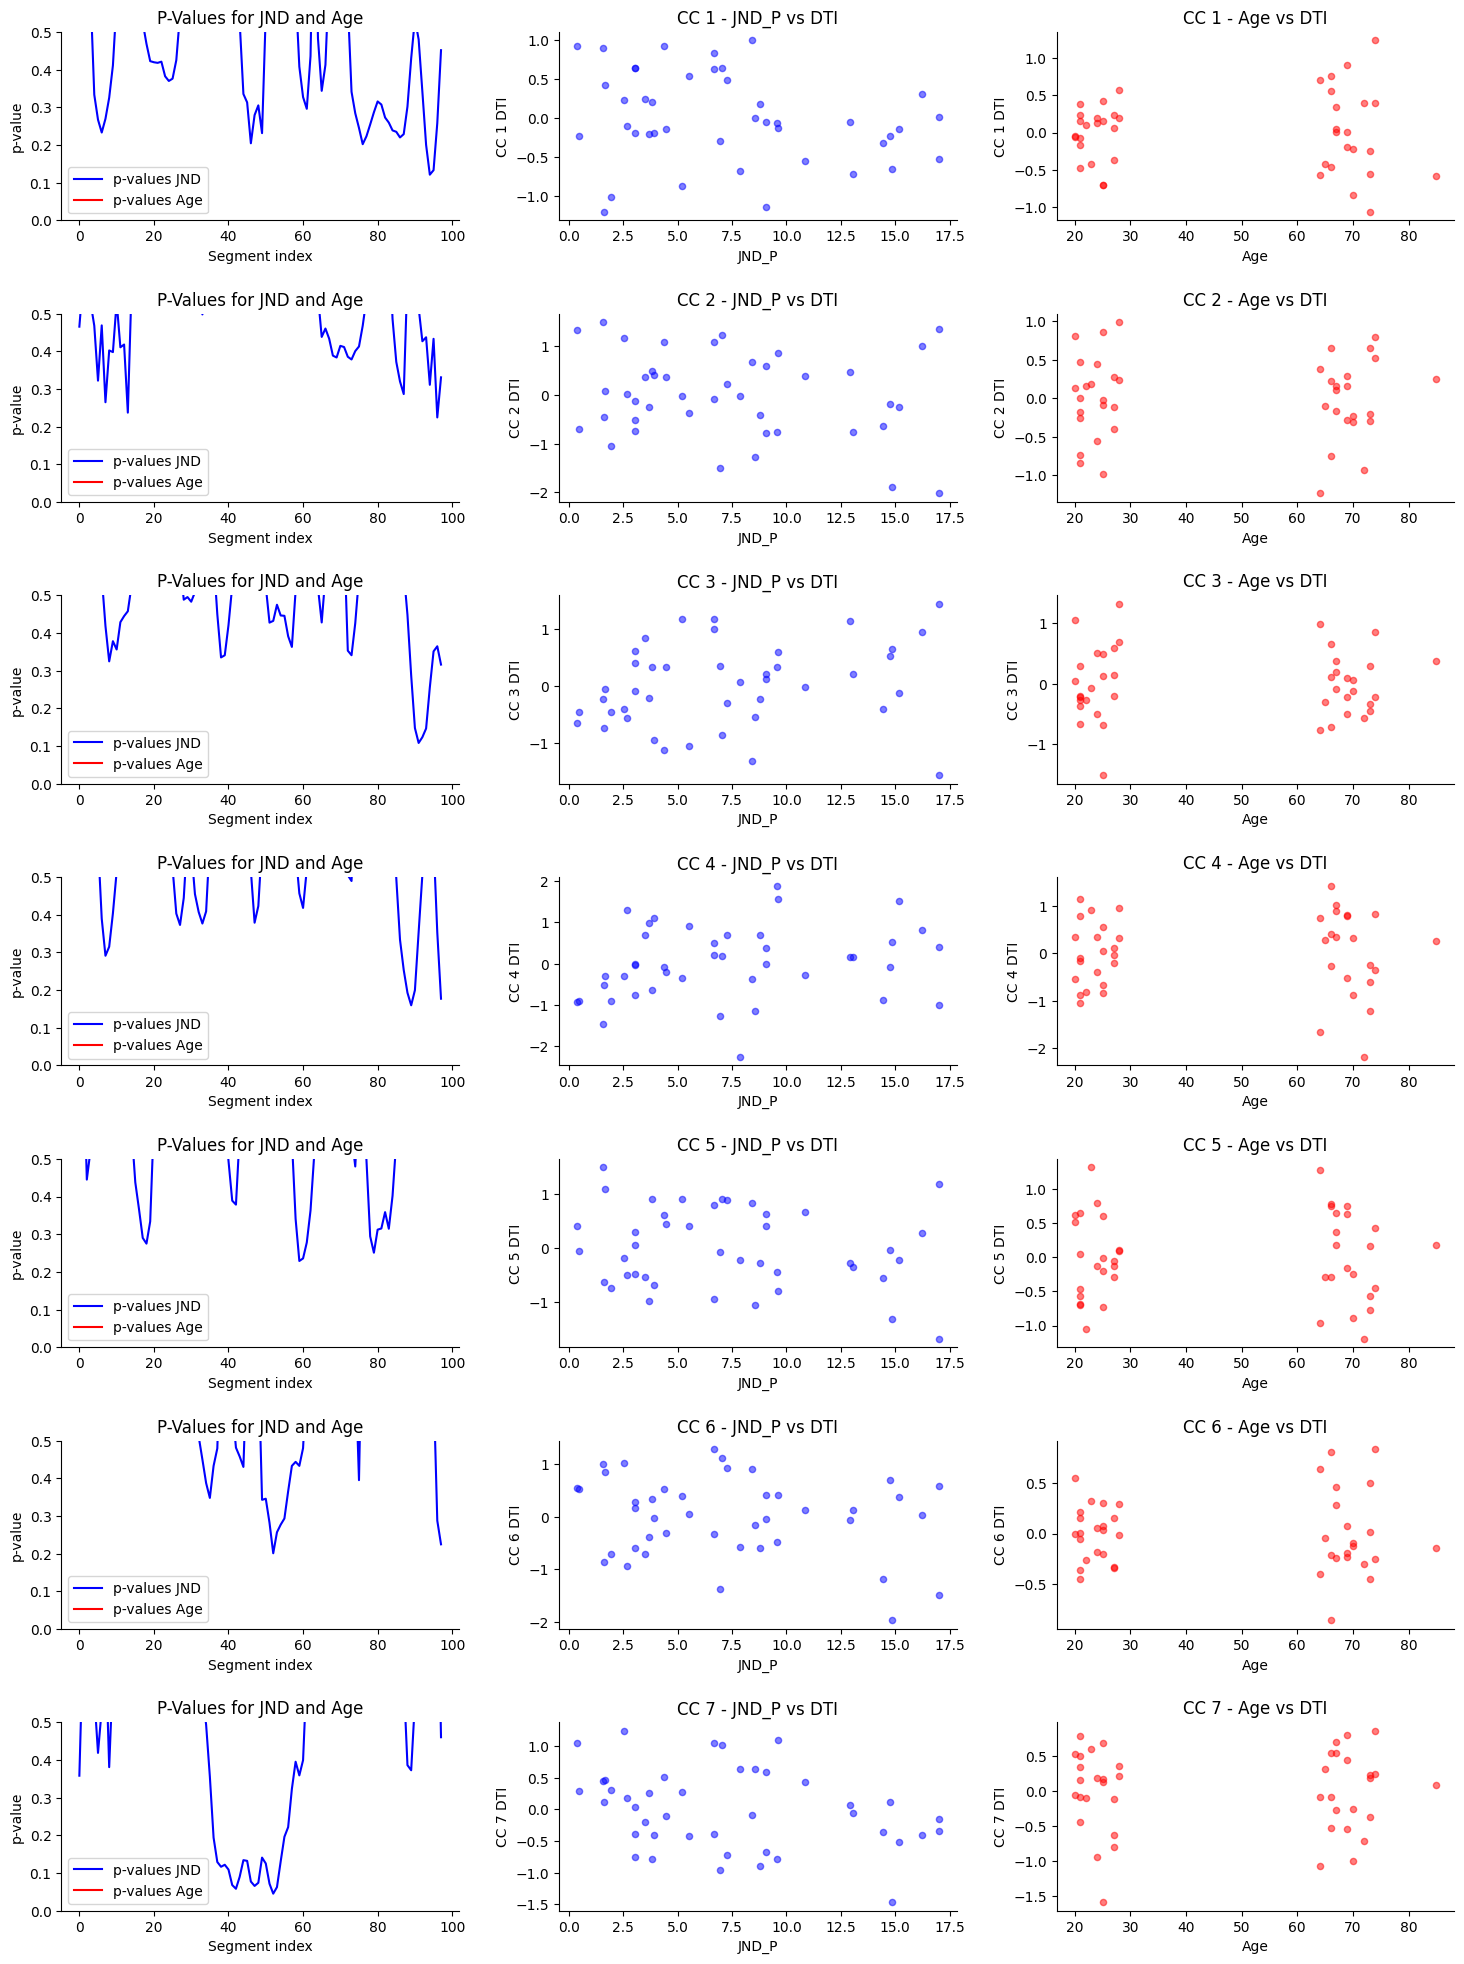

In [107]:
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

print('Feat selection based on simple linear regression using f_regression\n')

for cc in range(1,8):
        
    f_statistic_jnd, p_values_jnd = f_regression(DTI_scaled[:,:,cc-1], jnd )
    f_statistic_age, p_values_age = f_regression(DTI_scaled[:,:,cc-1], age )

    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age)[:97]
    
    print(f'CC {cc} - Best features for JND: {f_reg_best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {f_reg_best_features_age_cc[:10]}')

    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')

    axs[cc-1,0].set_ylim(0, 0.5)
    axs[cc-1,0].set_xlabel('Segment index')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=f_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=f_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    
plt.tight_layout(pad=2.0)



based on r_regression

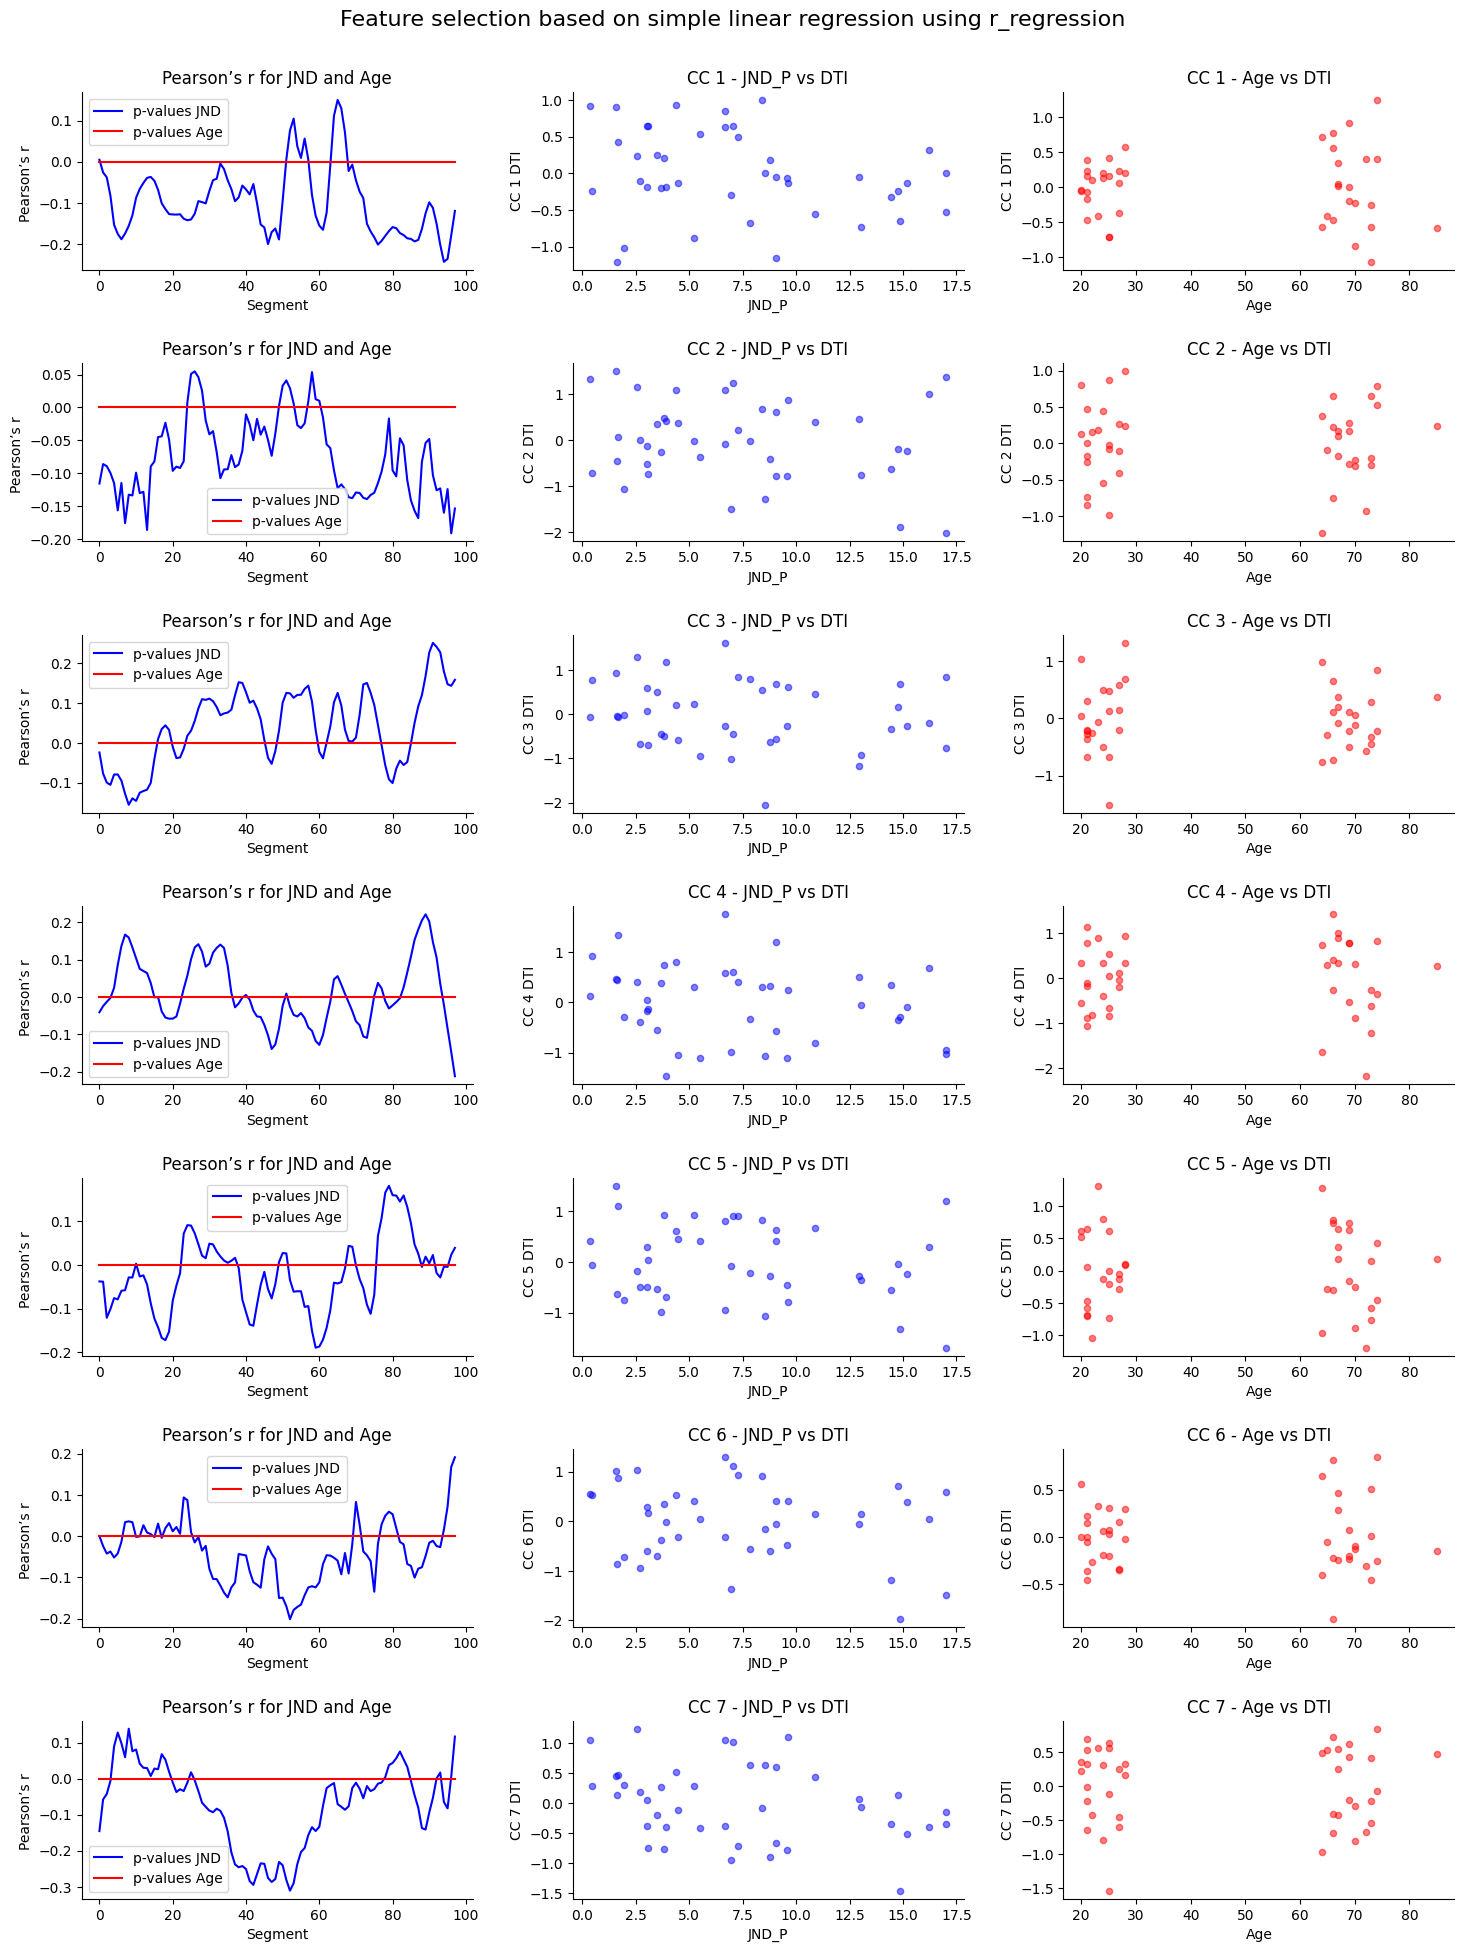

In [108]:
from sklearn.feature_selection import r_regression

####

from sklearn.feature_selection import r_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI_scaled[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI_scaled[:,:,cc-1], age)

    r_reg_age_allcc[cc-1,:] = r_reg_age
    
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)[:97]
    r_reg_best_features_age_cc = np.argsort(r_reg_age)[:97]



  
    
    if metricsDTI=='FA':
        r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]
    else: 
        r_reg_best_features_jnd_cc_allCC[cc-1,:] = r_reg_best_features_jnd_cc[-10:]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[-10:]

    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')  
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

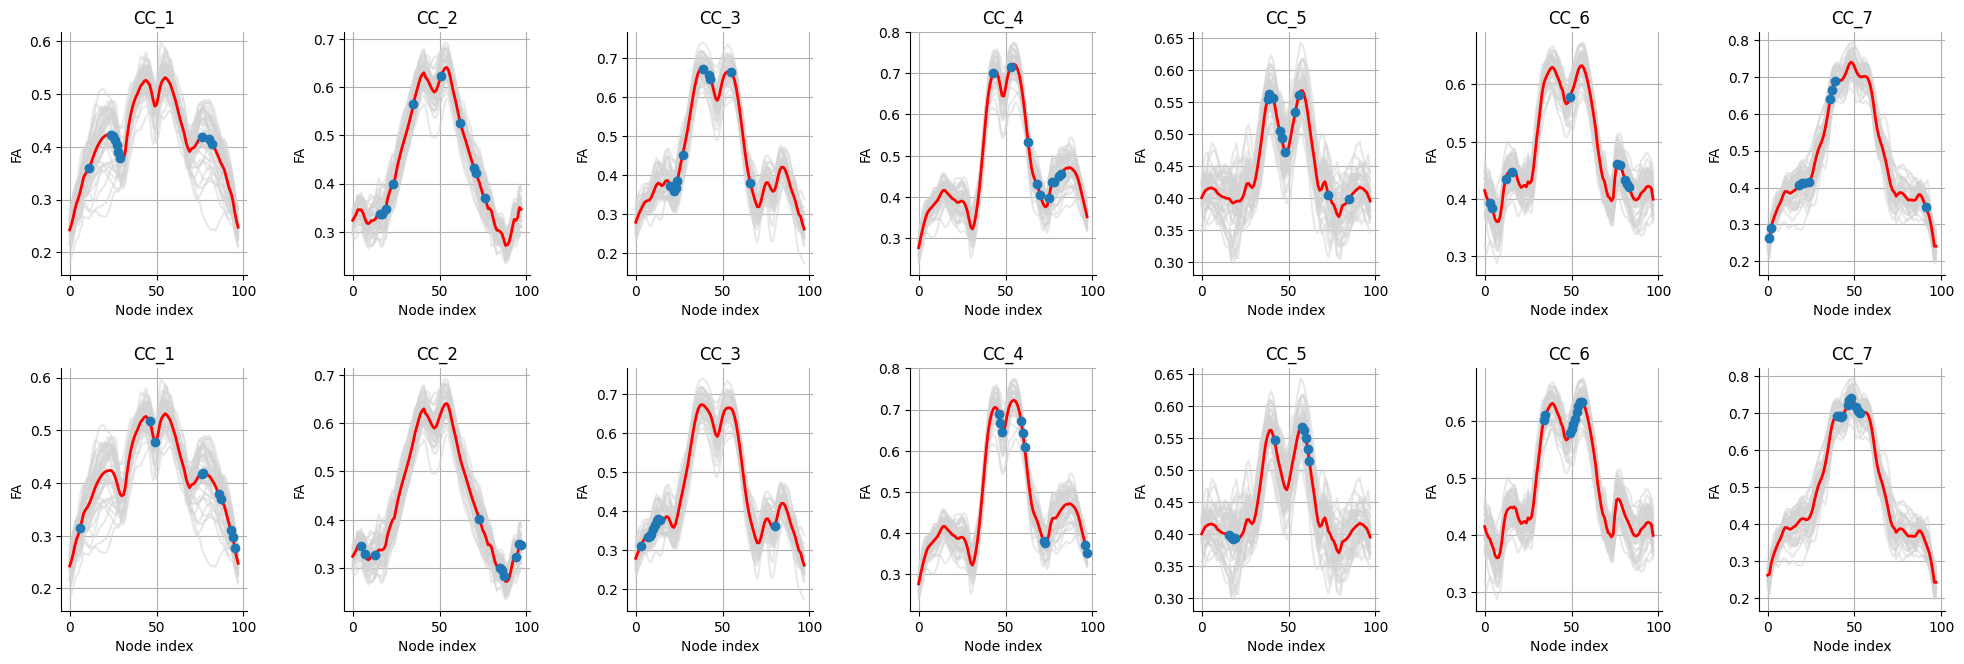

In [109]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(r_reg_best_features_age_cc_allCC[i,:], DTI[:,r_reg_best_features_age_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)



In [110]:
r_reg_best_features_jnd_cc_allCC

array([[94, 95, 93, 76, 46, 86, 77, 87, 49,  6],
       [96, 13,  7, 87, 94, 86,  5, 97, 85, 73],
       [ 8, 10,  9,  7, 11, 12, 13,  3, 80, 14],
       [97, 96, 47, 60, 48, 59, 73, 72, 46, 61],
       [59, 60, 18, 61, 17, 19, 58, 62, 16, 42],
       [52, 53, 54, 51, 55, 49, 50, 35, 56, 34],
       [52, 42, 53, 47, 41, 51, 48, 46, 43, 40]])

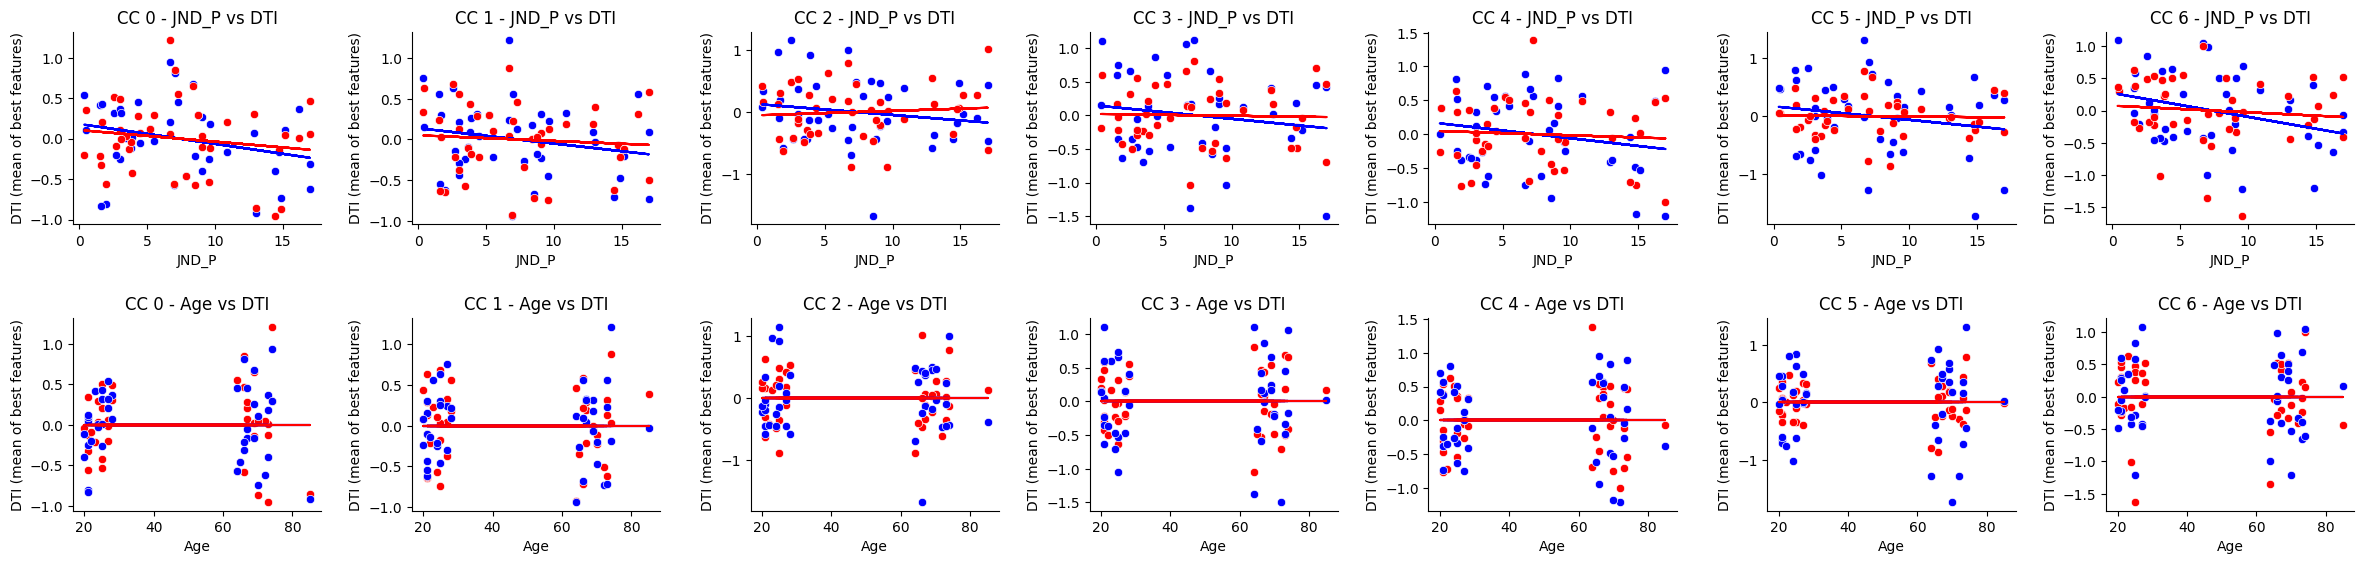

In [111]:
import statsmodels.api as sm
 

fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,6))

for cc in range(7):

    x = sm.add_constant(jnd)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2


    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='blue')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='red') 
    axs[0,cc].set_title(f'CC {cc} - JND_P vs DTI')
    axs[0,cc].spines['top'].set_visible(False)
    axs[0,cc].spines['right'].set_visible(False)
    axs[0,cc].set_xlabel('JND_P')
    axs[0,cc].set_ylabel('DTI (mean of best features)')
    # Tracer la ligne de régression
    axs[0,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[0,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')



    
    x = sm.add_constant(age)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='red')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='blue')
    axs[1,cc].set_title(f'CC {cc} - Age vs DTI')
    axs[1,cc].spines['top'].set_visible(False)
    axs[1,cc].spines['right'].set_visible(False)
    axs[1,cc].set_xlabel('Age')
    axs[1,cc].set_ylabel('DTI (mean of best features)')
    axs[1,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[1,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')

plt.tight_layout(pad=2.0)



       


Regression prediction test on cc 7 best feat

[39 37  1 36 21 24 91  2 20 18]
[52 42 53 47 41 51 48 46 43 40]
Mean MSE for JND: 31.1884 ± 11.1118
Mean MSE for Age: 1114.3102 ± 200.0638
P-value from independent t-test: 0.0000
Mean R² for JND: -0.5417 ± 0.7202
Mean R² for Age: -1.3472 ± 0.6996
P-value from independent t-test: 0.0000
Mean MAE for JND: 4.7053 ± 0.8745
Mean MAE for Age: 28.5638 ±   3.2635
P-value from independent t-test: 0.0000


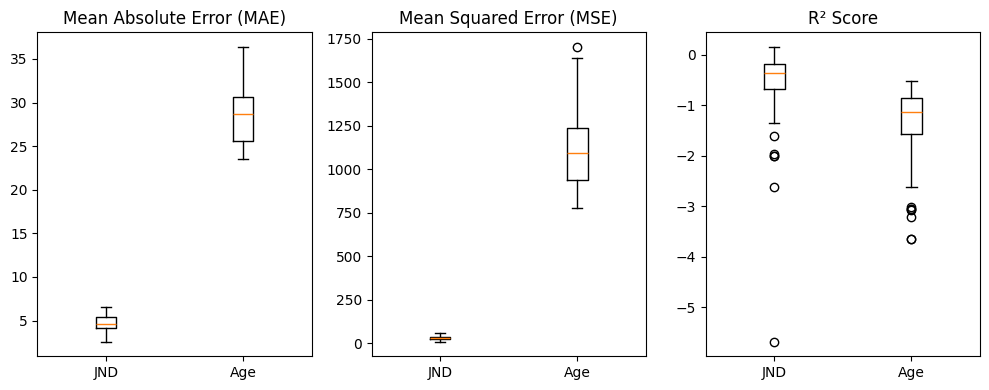

In [112]:
cc=6
print(r_reg_best_features_age_cc_allCC[cc])
print(r_reg_best_features_jnd_cc_allCC[cc])

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel as t_test_rel, ttest_ind as t_test_ind

mae_jnd_rd = []
mae_age_rd = []
mse_jnd_rd = []
mse_age_rd = []
r2_jnd_rd = []
r2_age_rd = []

for rd in range(100):

    X_train,X_test,y_train,y_test=train_test_split(DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc], jnd, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)

    mae_jnd_rd.append(mean_absolute_error(y_test, y_pred))
    mse_jnd_rd.append(mean_squared_error(y_test, y_pred))
    r2_jnd_rd.append(r2_score(y_test, y_pred))

    X_train,X_test,y_train,y_test=train_test_split(DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc], age, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)
  
    mae_age_rd.append(mean_absolute_error(y_test, y_pred))
    mse_age_rd.append(mean_squared_error(y_test, y_pred))
    r2_age_rd.append(r2_score(y_test, y_pred))




fig,ax=plt.subplots(nrows=1, ncols=3,figsize=(10,4))
ax[0].boxplot([mae_jnd_rd, mae_age_rd], labels=['JND', 'Age'])
ax[0].set_title('Mean Absolute Error (MAE)')
ax[1].boxplot([mse_jnd_rd, mse_age_rd], labels=['JND', 'Age'])
ax[1].set_title('Mean Squared Error (MSE)')
ax[2].boxplot([r2_jnd_rd, r2_age_rd], labels=['JND', 'Age'])
ax[2].set_title('R² Score')
plt.tight_layout()

t,pvalue=t_test_ind(mse_jnd_rd, mse_age_rd)
print(f'Mean MSE for JND: {np.mean(mse_jnd_rd):.4f} ± {np.std(mse_jnd_rd):.4f}')
print(f'Mean MSE for Age: {np.mean(mse_age_rd):.4f} ± {np.std(mse_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(r2_jnd_rd, r2_age_rd)
print(f'Mean R² for JND: {np.mean(r2_jnd_rd):.4f} ± {np.std(r2_jnd_rd):.4f}')
print(f'Mean R² for Age: {np.mean(r2_age_rd):.4f} ± {np.std(r2_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(mae_jnd_rd, mae_age_rd)
print(f'Mean MAE for JND: {np.mean(mae_jnd_rd):.4f} ± {np.std(mae_jnd_rd):.4f}')
print(f'Mean MAE for Age: {np.mean(mae_age_rd):.4f} ±   {np.std(mae_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

In [113]:


DTI_JND=pd.DataFrame([])
DTI_AGE=pd.DataFrame([])
for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_scaled[:,f_reg_best_features_jnd_cc_allCC[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in f_reg_best_features_jnd_cc_allCC[cc-1]]
    DTI_JND=pd.concat([DTI_JND, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_scaled[:,f_reg_best_features_age_cc_allCC[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in f_reg_best_features_age_cc_allCC[cc-1]]
    DTI_AGE=pd.concat([DTI_AGE, DTI_AGE_tmp], axis=1)




DTI_JND.describe()


,CC1_94,CC1_95,CC1_93,CC1_76,CC1_46,CC1_86,CC1_77,CC1_87,CC1_49,CC1_6,...,CC7_52,CC7_42,CC7_53,CC7_47,CC7_41,CC7_51,CC7_48,CC7_46,CC7_43,CC7_40
count,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,...,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01
mean,1.665335e-16,1.202742e-16,-5.286776e-18,2.154361e-16,8.723181e-17,1.427430e-16,1.942890e-16,8.194503e-17,1.242392e-16,2.537653e-16,...,1.453863e-16,1.037530e-16,1.063964e-16,7.137148e-17,2.167578e-16,9.516197e-17,4.493760e-17,2.775558e-17,2.669822e-16,-2.643388e-18
std,5.843044e-01,5.767612e-01,5.530787e-01,5.660120e-01,6.233525e-01,4.984178e-01,5.966825e-01,5.626483e-01,7.758995e-01,6.091202e-01,...,6.311630e-01,6.284914e-01,6.789791e-01,7.141911e-01,5.062631e-01,6.345750e-01,7.092177e-01,6.876795e-01,7.012113e-01,5.162696e-01
min,-1.207727e+00,-1.280354e+00,-1.143250e+00,-1.356747e+00,-1.382896e+00,-1.333878e+00,-1.572624e+00,-1.343664e+00,-1.897684e+00,-1.209322e+00,...,-1.463545e+00,-1.304238e+00,-1.452125e+00,-1.686639e+00,-1.184848e+00,-1.555562e+00,-1.768293e+00,-1.517411e+00,-1.473748e+00,-1.368010e+00
25%,-2.794309e-01,-3.059293e-01,-3.634157e-01,-3.129683e-01,-4.823420e-01,-4.024570e-01,-3.760483e-01,-4.241602e-01,-3.841861e-01,-4.047814e-01,...,-4.070923e-01,-4.668029e-01,-4.110402e-01,-4.191321e-01,-3.453922e-01,-4.677960e-01,-4.869423e-01,-5.044103e-01,-5.024407e-01,-4.065255e-01
50%,-6.396602e-02,1.556977e-02,4.826922e-02,1.646926e-01,3.583846e-02,1.150906e-01,1.031034e-01,9.752555e-02,9.306062e-02,4.260467e-03,...,-8.635110e-03,6.200128e-02,-3.157528e-02,5.058870e-02,5.163398e-02,4.083334e-02,4.245603e-02,2.073365e-02,6.507171e-02,8.424158e-02
75%,4.765101e-01,3.018152e-01,4.729095e-01,3.336259e-01,5.100704e-01,3.283706e-01,3.670685e-01,4.019008e-01,5.289244e-01,3.506719e-01,...,4.402297e-01,3.799707e-01,4.898183e-01,4.805436e-01,3.283781e-01,4.026046e-01,5.481406e-01,4.783342e-01,4.336876e-01,3.923232e-01
max,9.981613e-01,1.134069e+00,1.050948e+00,1.344258e+00,1.045051e+00,9.867901e-01,1.485683e+00,1.177269e+00,1.636770e+00,1.296880e+00,...,1.238424e+00,1.172257e+00,1.270678e+00,1.317176e+00,9.012773e-01,1.156932e+00,1.217127e+00,1.316446e+00,1.494512e+00,8.007271e-01


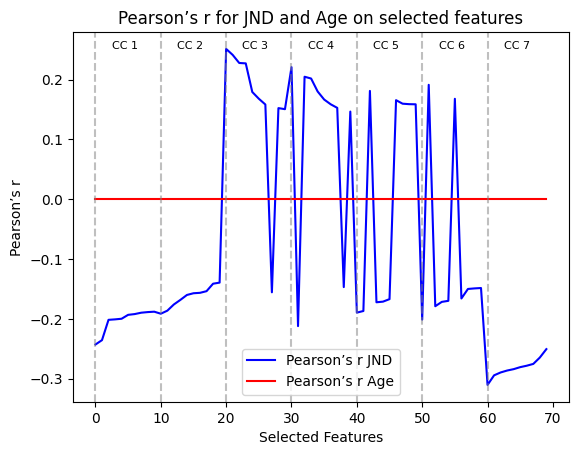

In [114]:
cc=1
r_reg_jnd70 = r_regression(DTI_JND, jnd)
r_reg_age70 = r_regression(DTI_AGE, age)


plt.plot(r_reg_jnd70, color='blue', label='Pearson’s r JND')
plt.plot(r_reg_age70, color='red', label='Pearson’s r Age')
plt.xlabel('Selected Features')
plt.ylabel('Pearson’s r')
plt.title('Pearson’s r for JND and Age on selected features')
plt.legend()

for i in range(7):
    plt.axvline(x=i*10, color='gray', linestyle='--', alpha=0.5)
    plt.text(i*10 + 2.5, max(max(r_reg_jnd70), max(r_reg_age70)), f'CC {i+1}', color='black', fontsize=8)


In [115]:
Aging_INDICES['JND_group3'] = pd.qcut(Aging_INDICES['JND_P'], q=3, labels=[0,1,2])


CC 1: P-value for the overall model: 0.0829
CC 2: P-value for the overall model: 0.1907
CC 3: P-value for the overall model: 0.1697
CC 4: P-value for the overall model: 0.3282
CC 5: P-value for the overall model: 0.8794
CC 6: P-value for the overall model: 0.4566
CC 7: P-value for the overall model: 0.0408


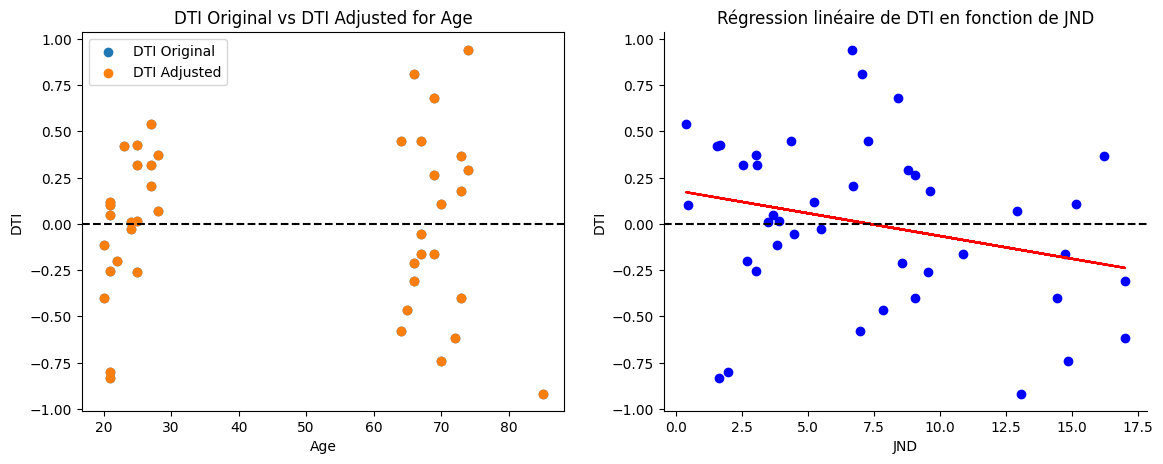

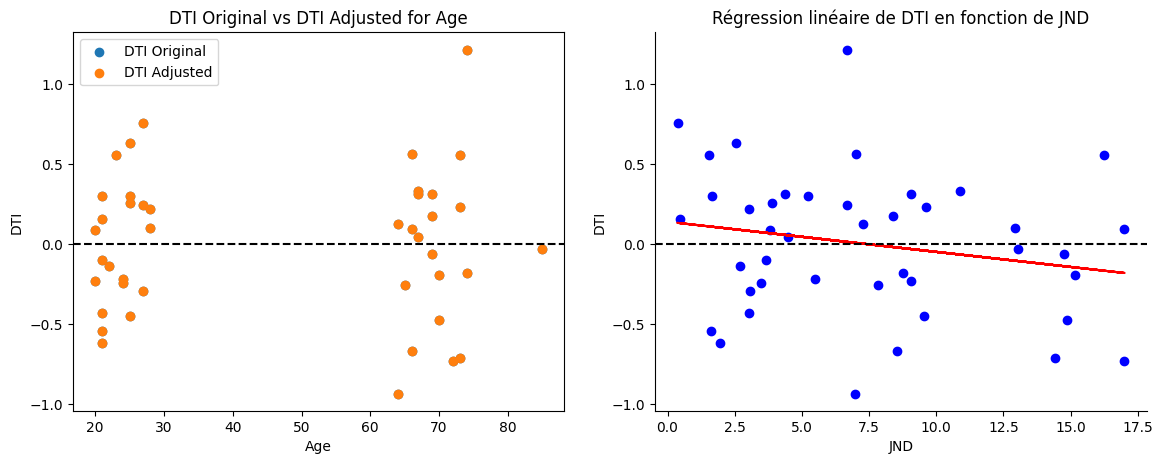

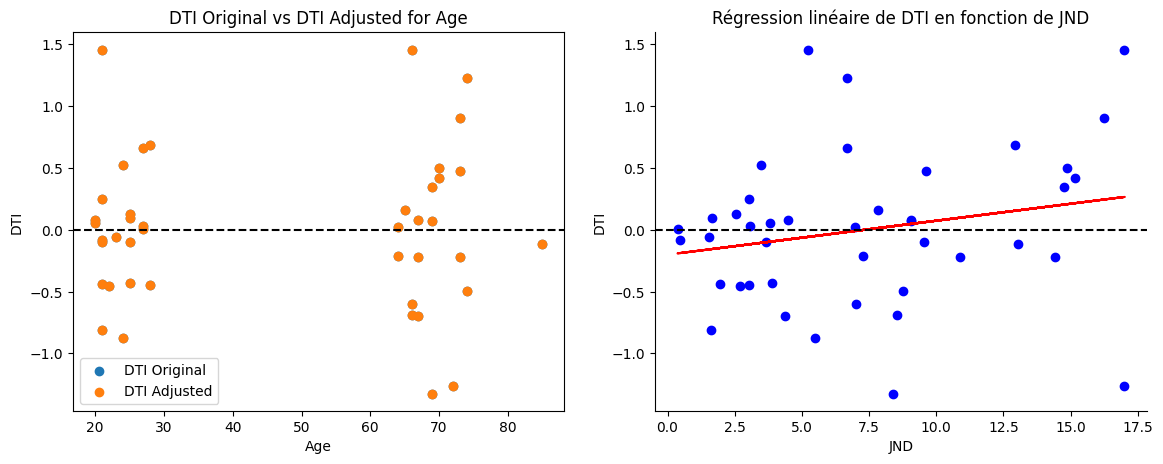

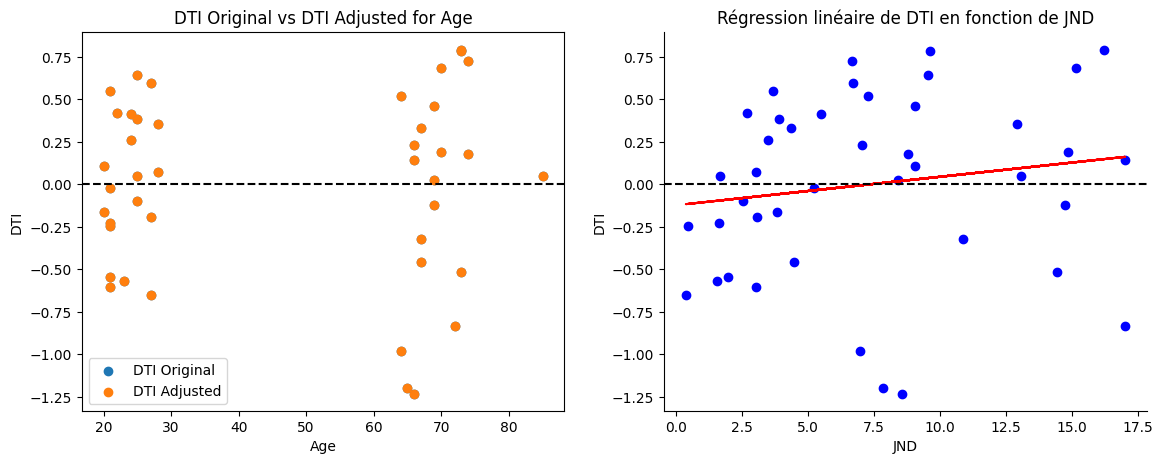

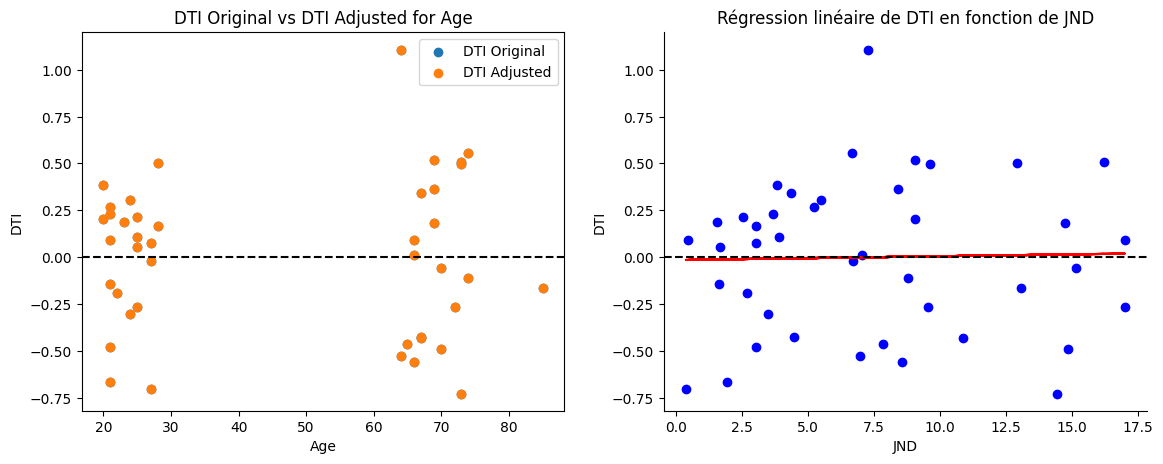

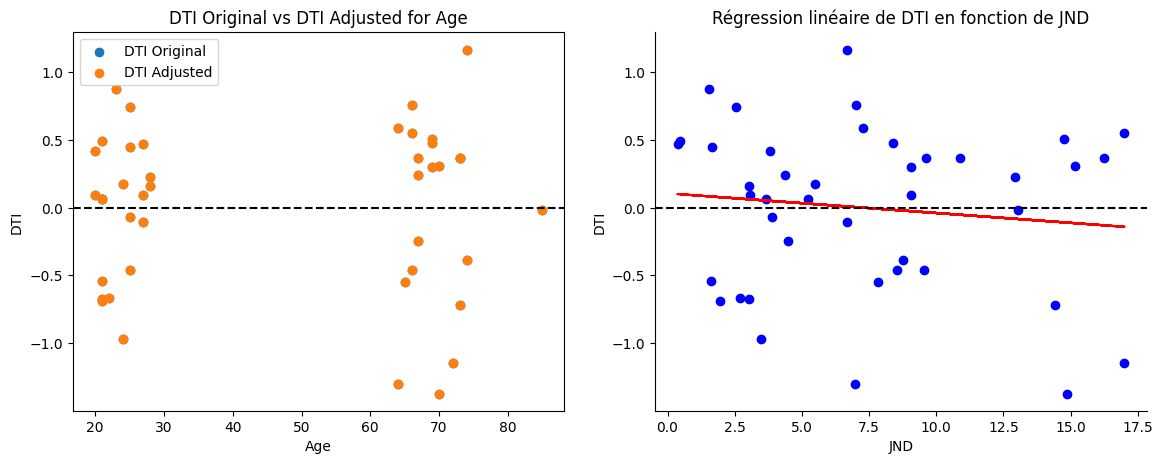

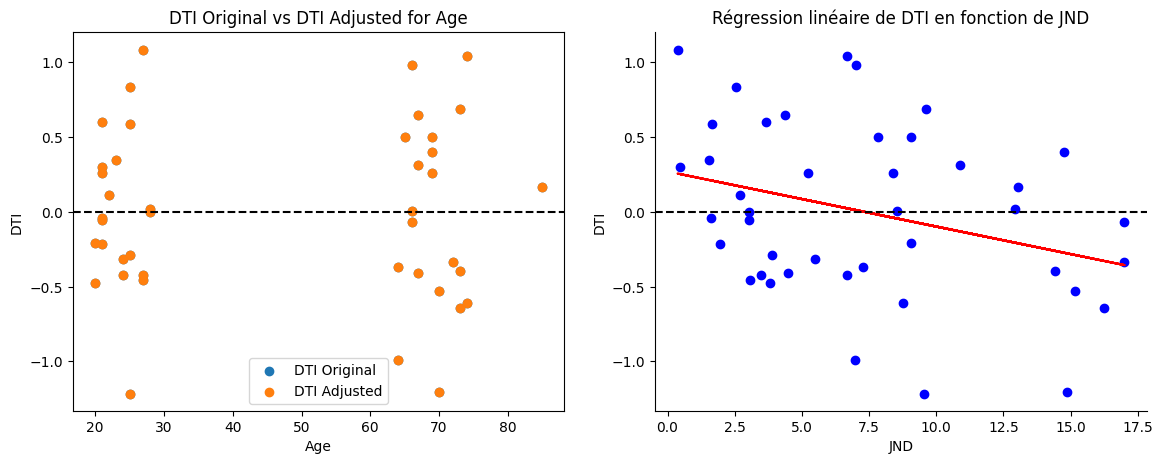

In [116]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

for cc in range(1,8):
        
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)

    data_adjusted = data.copy()

    ### enlever l'effet de l'âge sur le DTI

    # Ajouter une constante à la variable indépendante
    X = sm.add_constant(age)
    y = data

    # Créer le modèle de régression multiple
    model = sm.OLS(y, X)

    # Ajuster le modèle
    results = model.fit()   

    # Calculer les résidus
    residuals = results.resid

    # Mettre à jour les données DTI avec les résidus
    data_adjusted = residuals

    ## test l effet du JND sur le DTI ajusté pour l'âge

    X = sm.add_constant(jnd)
    y = data_adjusted.values

    model = sm.OLS(y, X)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    regression_line = slope * jnd + intercept


    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    axs[0].scatter(age, data, label='DTI Original')
    axs[0].scatter(age, data_adjusted, label='DTI Adjusted')
    axs[0].set_xlabel('Age')
    axs[0].set_ylabel('DTI')
    axs[0].legend()
    axs[0].axhline(0, color='black', linestyle='--', label='Zero Line')
    axs[0].set_title('DTI Original vs DTI Adjusted for Age')

    axs[1].scatter(jnd, data_adjusted, color='blue', label='Données')
    axs[1].plot(jnd, regression_line, color='red', label='Régression linéaire')
    axs[1].set_xlabel('JND')
    axs[1].set_ylabel('DTI')
    axs[1].set_title('Régression linéaire de DTI en fonction de JND')
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['right'].set_visible(False)
    axs[1].axhline(0, color='black', linestyle='--', label='Zero Line')
    plt.tight_layout(pad=2.0)

    # Afficher le graphique
    # print(results.summary())
    f_pvalue = results.f_pvalue
    print(f'CC {cc}: P-value for the overall model: {f_pvalue:.4f}')


In [117]:
    
data = DTI_JND[DTI_JND.columns[best_DTI_JND_features].tolist()].mean(axis=1)

data_adjusted = data.copy()

### enlever l'effet de l'âge sur le DTI

# Ajouter une constante à la variable indépendante
X = sm.add_constant(age)
y = data

# Créer le modèle de régression multiple
model = sm.OLS(y, X)

# Ajuster le modèle
results = model.fit()   

# Calculer les résidus
residuals = results.resid

# Mettre à jour les données DTI avec les résidus
data_adjusted = residuals

## test l effet du JND sur le DTI ajusté pour l'âge

X = sm.add_constant(jnd)
y = data_adjusted.values

model = sm.OLS(y, X)
results = model.fit()
slope = results.params[1]
intercept = results.params[0]
regression_line = slope * jnd + intercept

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

axs[0].scatter(age, data, label='DTI Original')
axs[0].scatter(age, data_adjusted, label='DTI Adjusted')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('DTI')
axs[0].legend()
axs[0].axhline(0, color='black', linestyle='--', label='Zero Line')
axs[0].set_title('DTI Original vs DTI Adjusted for Age')

axs[1].scatter(jnd, data_adjusted, color='blue', label='Données')
axs[1].plot(jnd, regression_line, color='red', label='Régression linéaire')
axs[1].set_xlabel('JND')
axs[1].set_ylabel('DTI')
axs[1].set_title('Régression linéaire de DTI en fonction de JND')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].axhline(0, color='black', linestyle='--', label='Zero Line')
plt.tight_layout(pad=2.0)

# Afficher le graphique
# print(results.summary())
f_pvalue = results.f_pvalue
print(f'P-value for the overall model: {f_pvalue:.4f}')


NameError: name 'best_DTI_JND_features' is not defined

                            OLS Regression Results                            
Dep. Variable:                    jnd   R-squared:                       0.589
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     28.00
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           2.89e-08
Time:                        15:25:11   Log-Likelihood:                -107.21
No. Observations:                  42   AIC:                             220.4
Df Residuals:                      39   BIC:                             225.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5622      1.112      0.506      0.6

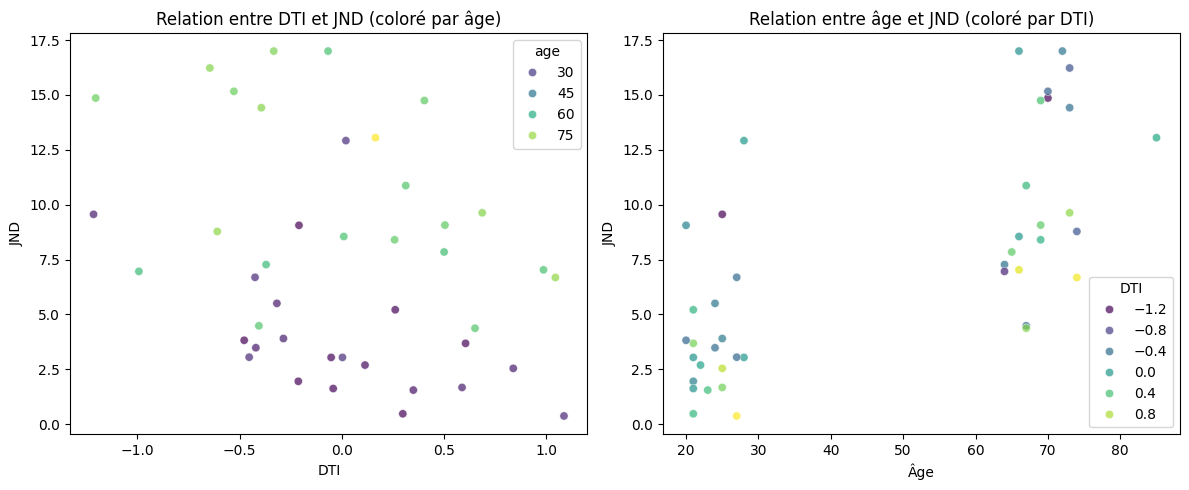

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

pvaDTIlue = []

for cc in range(1,8):
            
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'jnd': jnd   # Variable dépendante
    })

    # 2. Préparer les variables pour la régression
    X = df[['DTI', 'age']]  # Variables explicatives
    X = sm.add_constant(X)  # Ajoute une constante pour l'interception
    y = df['jnd']  # Variable à expliquer

    # 3. Ajuster le modèle de régression multiple
    model = sm.OLS(y, X).fit()

    pvaDTIlue.append(model.pvalues['DTI'])

print(model.summary())

# 4. Afficher les résultats de manière claire
print("\n--- Résultats de la régression ---")
print(f"Coefficient du DTI : {model.params['DTI']:.4f}")
print(f"P-valeur du DTI : {model.pvalues['DTI']:.4f}")
print(f"Coefficient de l'âge : {model.params['age']:.4f}")
print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
print(f"R-carré : {model.rsquared:.3f}")
print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

# 5. Visualisation
plt.figure(figsize=(12, 5))

# Scatter plot : DTI vs JND, coloré par âge
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='DTI', y='jnd', hue='age', palette='viridis', alpha=0.7)
plt.title("Relation entre DTI et JND (coloré par âge)")
plt.xlabel("DTI")
plt.ylabel("JND")

# Scatter plot : Age vs JND
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='jnd', hue='DTI', palette='viridis', alpha=0.7)
plt.title("Relation entre âge et JND (coloré par DTI)")
plt.xlabel("Âge")
plt.ylabel("JND")

plt.tight_layout()
plt.show()

In [ ]:
import emoji

print('_____________________' + metricsDTI+ '_____________________')
for cc in range(7):
    print('________________________________________')
    print(metricsDTI + '  \ segment cc: ', cc+1, f_reg_best_features_jnd_cc_allCC[cc,:].tolist())
    print('p-value  pour cc {}: {:.4}'.format(cc+1, pvaDTIlue[cc] ))
    if pvaDTIlue[cc] * 7 < 0.05:
        emojipv=emoji.emojize(':check_mark_button:')
    else:        emojipv=emoji.emojize(':cross_mark:')
    print('p-value ajustée pour cc {}: {:.4f}'.format(cc+1, pvaDTIlue[cc] * 7), emojipv)

_____________________FA_____________________
________________________________________
FA  \ segment cc:  1 [94, 95, 93, 76, 46, 86, 77, 87, 49, 6]
p-value  pour cc 1: 0.01463
p-value ajustée pour cc 1: 0.1024 ❌
________________________________________
FA  \ segment cc:  2 [96, 13, 7, 87, 94, 86, 5, 97, 85, 73]
p-value  pour cc 2: 0.06779
p-value ajustée pour cc 2: 0.4745 ❌
________________________________________
FA  \ segment cc:  3 [91, 92, 93, 90, 94, 89, 97, 8, 38, 39]
p-value  pour cc 3: 0.05496
p-value ajustée pour cc 3: 0.3847 ❌
________________________________________
FA  \ segment cc:  4 [89, 97, 88, 90, 87, 7, 8, 86, 96, 91]
p-value  pour cc 4: 0.1743
p-value ajustée pour cc 4: 1.2203 ❌
________________________________________
FA  \ segment cc:  5 [59, 60, 79, 18, 61, 17, 78, 80, 83, 81]
p-value  pour cc 5: 0.834
p-value ajustée pour cc 5: 5.8379 ❌
________________________________________
FA  \ segment cc:  6 [52, 97, 53, 54, 51, 96, 55, 49, 50, 35]
p-value  pour cc 6: 0.3022

In [ ]:
for cc in range(7):
    print('segment cc: ', cc+1, r_reg_best_features_jnd_cc_allCC[cc,:].tolist())

segment cc:  1 [94, 95, 93, 76, 46, 86, 77, 87, 49, 6]
segment cc:  2 [96, 13, 7, 87, 94, 86, 5, 97, 85, 73]
segment cc:  3 [8, 10, 9, 7, 11, 12, 13, 3, 80, 14]
segment cc:  4 [97, 96, 47, 60, 48, 59, 73, 72, 46, 61]
segment cc:  5 [59, 60, 18, 61, 17, 19, 58, 62, 16, 42]
segment cc:  6 [52, 53, 54, 51, 55, 49, 50, 35, 56, 34]
segment cc:  7 [52, 42, 53, 47, 41, 51, 48, 46, 43, 40]


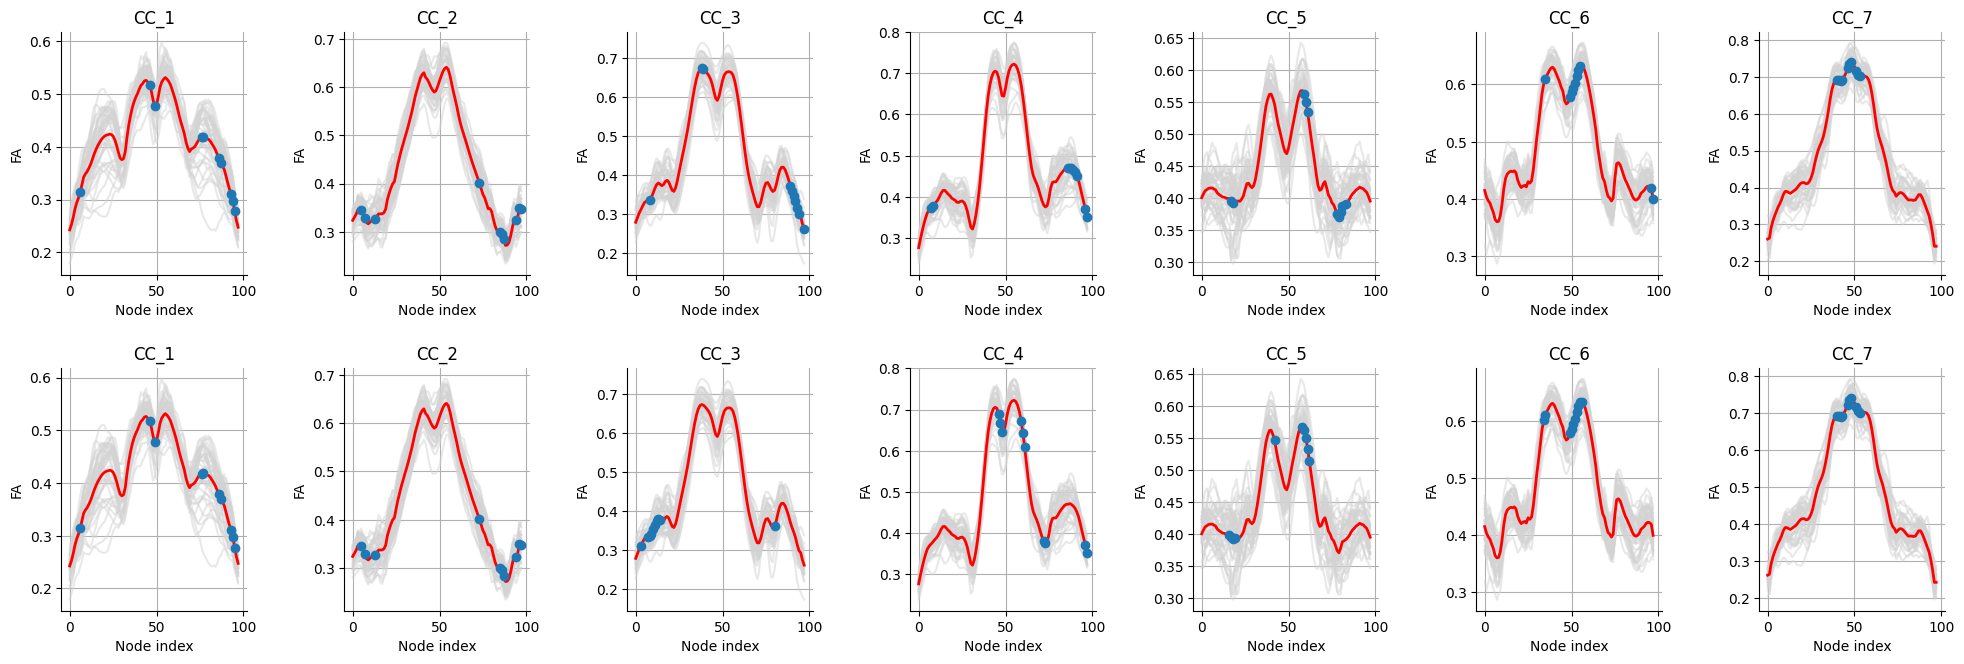

In [ ]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(f_reg_best_features_jnd_cc_allCC[i,:], DTI[:,f_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)
